In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

In [2]:
monthly_gmv = pd.read_csv("D:/0/SQL/Project/data export/monthly gmv.csv")
category_performance = pd.read_csv("D:/0/SQL/Project/data export/category performance 2.csv")
delivery_review = pd.read_csv("D:/0/SQL/Project/data export/delivery review 2.csv")  
rfm = pd.read_csv("D:/0/SQL/Project/data export/RFM.csv")

In [3]:
monthly_gmv.head()

,order_month,total_gmv,total_orders,prev_month_gmv,growth_pct
0,2016-09,134.97,1,NaN,NaN
1,2016-10,40325.11,265,134.97,29777.09
2,2016-12,10.90,1,40325.11,-99.97
3,2017-01,111798.36,750,10.90,1025573.03
4,2017-02,234223.40,1653,111798.36,109.51


In [4]:
monthly_gmv.info()
monthly_gmv.describe()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_month     23 non-null     str    
 1   total_gmv       23 non-null     float64
 2   total_orders    23 non-null     int64  
 3   prev_month_gmv  22 non-null     float64
 4   growth_pct      22 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.0 KB


,total_gmv,total_orders,prev_month_gmv,growth_pct
count,23.000000,23.000000,22.000000,2.200000e+01
mean,574847.743913,4194.695652,562860.066818,4.797861e+04
std,337263.532856,2481.181398,340147.920596,2.184408e+05
min,10.900000,1.000000,10.900000,-9.997000e+01
25%,349934.265000,2424.500000,345301.972500,-4.715000e+00
50%,607399.670000,4193.000000,581049.685000,8.115000e+00
75%,862015.660000,6453.000000,864984.560000,3.957000e+01
max,987765.370000,7289.000000,987765.370000,1.025573e+06


In [5]:
monthly_gmv['order_month'] = pd.to_datetime(monthly_gmv['order_month'], format='%Y-%m')
monthly_gmv.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_month     23 non-null     datetime64[us]
 1   total_gmv       23 non-null     float64       
 2   total_orders    23 non-null     int64         
 3   prev_month_gmv  22 non-null     float64       
 4   growth_pct      22 non-null     float64       
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 1.0 KB


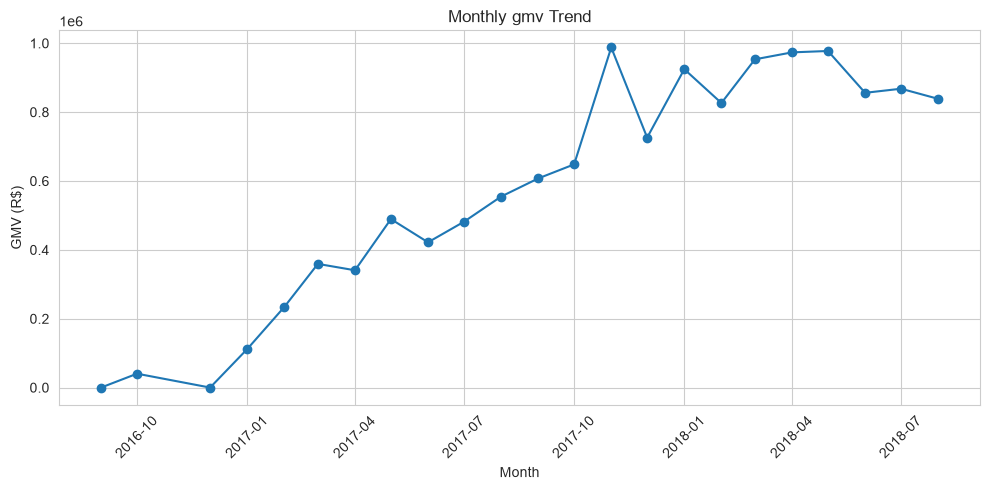

In [3]:
monthly_gmv['order_month'] = pd.to_datetime(monthly_gmv['order_month'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_gmv['order_month'], monthly_gmv['total_gmv'], marker='o')
ax.set_title('Monthly gmv Trend')
ax.set_xlabel('Month')
ax.set_ylabel('GMV (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
category_performance.head()

,product_category_name,total_orders,items_sold,avg_price,total_gmv,avg_review_score
0,beleza_saude,8601,9402,130.26,1224678.58,4.19
1,relogios_presentes,5454,5815,199.35,1159219.92,4.07
2,cama_mesa_banho,9177,10831,93.58,1013590.72,3.92
3,esporte_lazer,7486,8378,113.27,948960.45,4.17
4,informatica_acessorios,6499,7608,116.29,884760.96,3.99


In [5]:
category_performance.info()
category_performance.describe()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_category_name  73 non-null     str    
 1   total_orders           74 non-null     int64  
 2   items_sold             74 non-null     int64  
 3   avg_price              74 non-null     float64
 4   total_gmv              74 non-null     float64
 5   avg_review_score       74 non-null     float64
dtypes: float64(3), int64(2), str(1)
memory usage: 3.6 KB


,total_orders,items_sold,avg_price,total_gmv,avg_review_score
count,74.000000,74.000000,74.000000,7.400000e+01,74.000000
mean,1305.729730,1477.972973,145.603378,1.771621e+05,4.082973
std,2174.592907,2492.869634,143.464933,2.891741e+05,0.317040
min,2.000000,2.000000,26.720000,2.832900e+02,2.500000
25%,73.250000,75.000000,78.227500,7.012632e+03,3.975000
50%,239.000000,270.500000,114.780000,4.515224e+04,4.115000
75%,1347.500000,1621.750000,152.467500,1.815710e+05,4.220000
max,9177.000000,10831.000000,1071.020000,1.224679e+06,5.000000


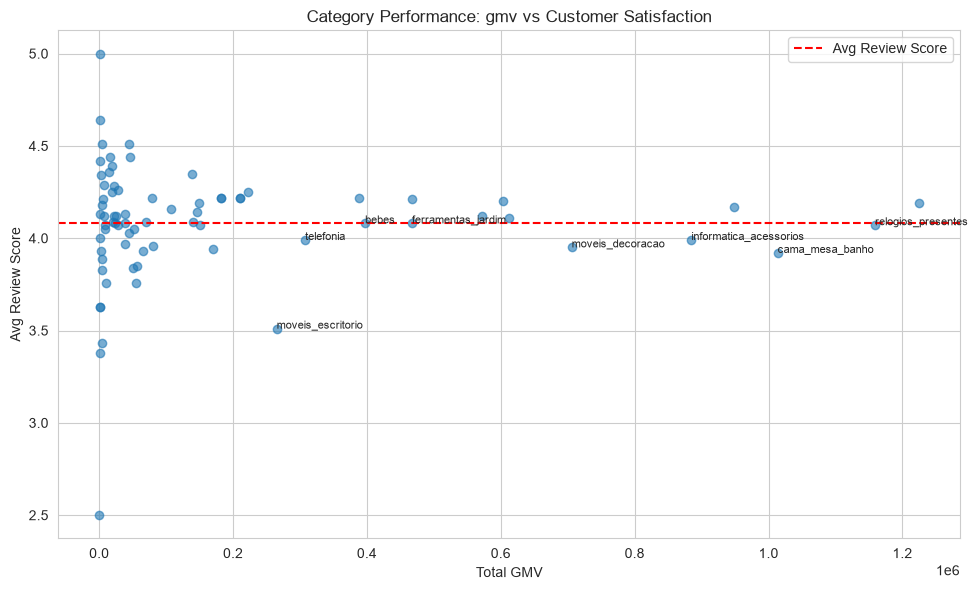

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(category_performance['total_gmv'], category_performance['avg_review_score'], alpha=0.6)
ax.axhline(category_performance['avg_review_score'].mean(), color='red', linestyle='--', label='Avg Review Score')
ax.set_xlabel('Total GMV')
ax.set_ylabel('Avg Review Score')
ax.set_title('Category Performance: gmv vs Customer Satisfaction')

priority = category_performance[
    (category_performance['total_gmv'] > category_performance['total_gmv'].quantile(0.75)) &
    (category_performance['avg_review_score'] < category_performance['avg_review_score'].mean())
]
for _, row in priority.iterrows():
    ax.annotate(row['product_category_name'], (row['total_gmv'], row['avg_review_score']), fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

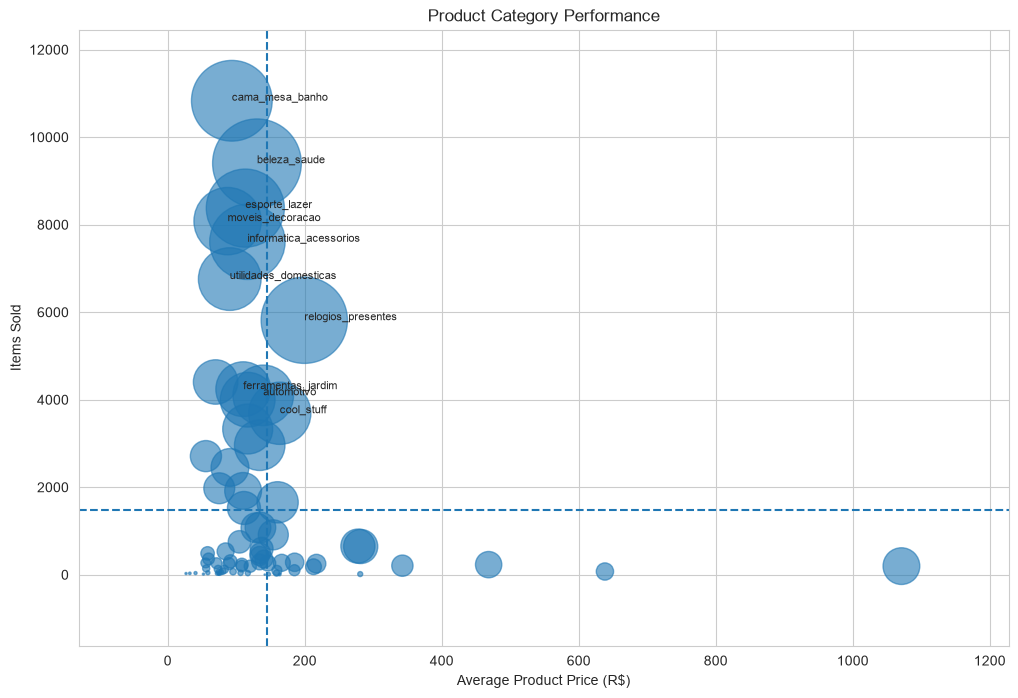

In [7]:
fig, ax = plt.subplots(figsize=(12,8))

bubble = ax.scatter(
    category_performance['avg_price'],
    category_performance['items_sold'],
    s=category_performance['total_gmv'] / 300,
    alpha=0.6
)

ax.set_title("Product Category Performance")
ax.set_xlabel("Average Product Price (R$)")
ax.set_ylabel("Items Sold")

ax.margins(x=0.15, y=0.15)

ax.axvline(
    category_performance['avg_price'].mean(),
    linestyle='--'
)

ax.axhline(
    category_performance['items_sold'].mean(),
    linestyle='--'
)

top_category = category_performance.nlargest(10, 'total_gmv')

for _, row in top_category.iterrows():
    ax.annotate(
        row['product_category_name'],
        (row['avg_price'], row['items_sold']),
        fontsize=8
    )

In [8]:
delivery_review.head()

,order_id,delay_days,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,-9,5
1,00018f77f2f0320c557190d7a144bdd3,-3,4
2,000229ec398224ef6ca0657da4fc703e,-14,5
3,00024acbcdf0a6daa1e931b038114c75,-6,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,-16,5


In [9]:
delivery_review.info()
delivery_review.describe()

<class 'pandas.DataFrame'>
RangeIndex: 95824 entries, 0 to 95823
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   order_id      95824 non-null  str  
 1   delay_days    95824 non-null  int64
 2   review_score  95824 non-null  int64
dtypes: int64(2), str(1)
memory usage: 2.2 MB


,delay_days,review_score
count,95824.000000,95824.000000
mean,-11.913070,4.155848
std,10.111737,1.284778
min,-147.000000,1.000000
25%,-17.000000,4.000000
50%,-12.000000,5.000000
75%,-7.000000,5.000000
max,188.000000,5.000000


In [10]:
# Korelasi
corr, p_value = stats.pearsonr(delivery_review['delay_days'], delivery_review['review_score'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.5f}")

# Kalau mau bandingkan 2 grup (Late vs On-time) pakai t-test
late = delivery_review[delivery_review['delay_days'] > 0]['review_score']
ontime = delivery_review[delivery_review['delay_days'] <= 0]['review_score']
t_stat, p_val = stats.ttest_ind(late, ontime, equal_var=False)
print(f"T-test: t={t_stat:.3f}, p={p_val:.5f}")

Correlation: -0.267, p-value: 0.00000
T-test: t=-100.745, p=0.00000


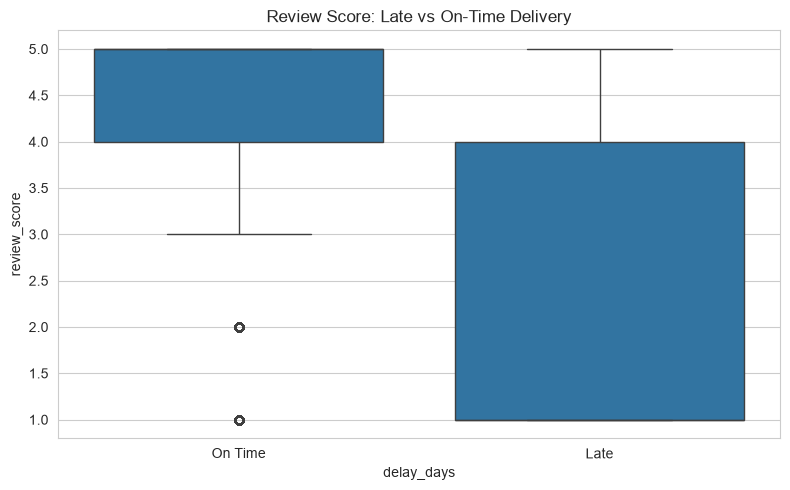

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=(delivery_review['delay_days'] > 0).map({True: 'Late', False: 'On Time'}), 
            y=delivery_review['review_score'], ax=ax)
ax.set_title('Review Score: Late vs On-Time Delivery')
plt.tight_layout()
plt.show()

In [12]:
delivery_review['delay_group'] = pd.cut(
    delivery_review['delay_days'],
    bins=[-100,-1,0,2,5,100],
    labels=[
        'Early',
        'On Time',
        '1-2 Days',
        '3-5 Days',
        '>5 Days'
    ]
)

delivery_review.groupby('delay_group')['review_score'].mean()

delay_group
Early       4.294040
On Time     4.033594
1-2 Days    3.513274
3-5 Days    2.469253
>5 Days     1.723357
Name: review_score, dtype: float64

In [17]:
delay_summary = (
    delivery_review
    .groupby('delay_group', observed=True)
    .agg(
        avg_review=('review_score', 'mean'),
        total_orders=('order_id', 'count')
    )
    .reset_index()
)

delay_summary

,delay_group,avg_review,total_orders
0,Early,4.294040,88158
1,On Time,4.033594,1280
2,1-2 Days,3.513274,1356
3,3-5 Days,2.469253,1366
4,>5 Days,1.723357,3622


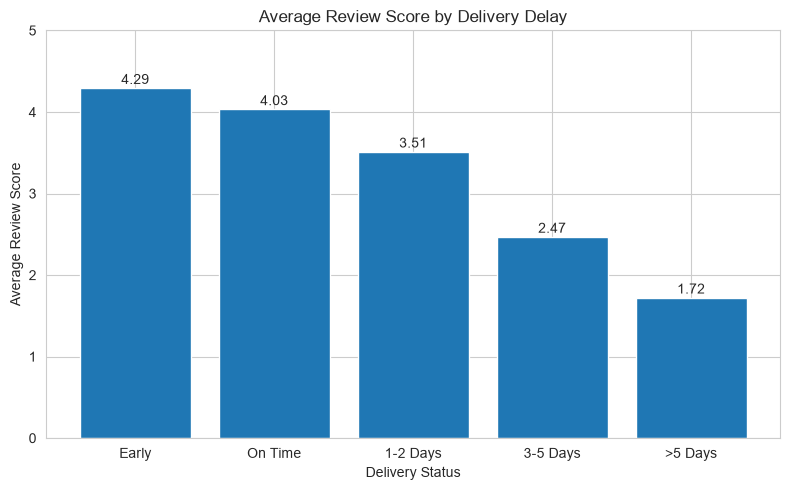

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    delay_summary['delay_group'],
    delay_summary['avg_review']
)

ax.set_title('Average Review Score by Delivery Delay')
ax.set_xlabel('Delivery Status')
ax.set_ylabel('Average Review Score')
ax.set_ylim(0,5)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f'{height:.2f}',
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

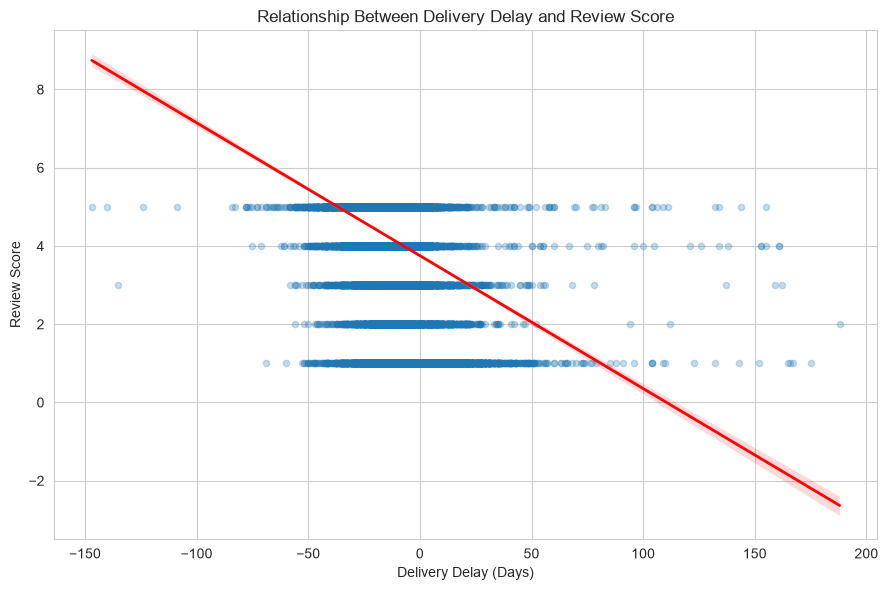

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=delivery_review,
    x='delay_days',
    y='review_score',
    scatter_kws={
        'alpha': 0.25,
        's': 20
    },
    line_kws={
        'color': 'red',
        'linewidth': 2
    },
    ax=ax
)

ax.set_title('Relationship Between Delivery Delay and Review Score')
ax.set_xlabel('Delivery Delay (Days)')
ax.set_ylabel('Review Score')

plt.tight_layout()
plt.show()

In [3]:
rfm.head()

,customer_unique_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score
0,d80730c15c647bc8f2ad77c908ba5ca9,127,1,0.85,3,1,1
1,b38211bd797f4fdd81a98b9d1754b606,127,1,0.85,3,1,1
2,317cfc692e3f86c45c95697c61c853a6,4,1,2.20,4,1,1
3,bd06ce0e06ad77a7f681f1a4960a3cc6,350,1,2.29,1,4,1
4,cf3839da0d9492ad151690b65f45d800,208,1,2.99,3,3,1


In [4]:
rfm.info()
rfm.describe()

<class 'pandas.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  93358 non-null  str    
 1   recency_days        93358 non-null  int64  
 2   frequency           93358 non-null  int64  
 3   monetary            93358 non-null  float64
 4   recency_score       93358 non-null  int64  
 5   frequency_score     93358 non-null  int64  
 6   monetary_score      93358 non-null  int64  
dtypes: float64(1), int64(5), str(1)
memory usage: 5.0 MB


,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score
count,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000,93358.000000
mean,237.478877,1.033420,141.621480,2.499979,2.499979,2.499979
std,152.595054,0.209097,215.694014,1.118040,1.118040,1.118040
min,0.000000,1.000000,0.850000,1.000000,1.000000,1.000000
25%,114.000000,1.000000,47.650000,1.250000,1.250000,1.250000
50%,218.000000,1.000000,89.730000,2.000000,2.000000,2.000000
75%,346.000000,1.000000,154.737500,3.000000,3.000000,3.000000
max,713.000000,15.000000,13440.000000,4.000000,4.000000,4.000000


In [10]:
rfm['rfm_score'] = rfm['recency_score'] + rfm['frequency_score'] + rfm['monetary_score']

def segment_customer(row):
    if row['rfm_score'] >= 10:
        return 'Champions'
    elif row['rfm_score'] >= 7:
        return 'Loyal Customers'
    elif row['recency_score'] <= 2 and row['frequency_score'] <= 2:
        return 'At Risk / Lost'
    else:
        return 'Potential Loyalist'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

segment_summary = (
    rfm.groupby('segment')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        total_gmv=('monetary', 'sum'),
        avg_spend=('monetary', 'mean')
    )
)

segment_summary['customer_pct'] = (
    segment_summary['customer_count']
    / segment_summary['customer_count'].sum()
    * 100
)

segment_summary['gmv_pct'] = (
    segment_summary['total_gmv']
    / segment_summary['total_gmv'].sum()
    * 100
)

segment_summary = segment_summary.round({
    'avg_spend': 2,
    'total_gmv': 2,
    'customer_pct': 2,
    'gmv_pct': 2
})

segment_order = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalist',
    'At Risk / Lost'
]

segment_summary = segment_summary.reindex(segment_order)

print(segment_summary)

                    customer_count   total_gmv  avg_spend  customer_pct  \
segment                                                                   
Champions                    10585  3573805.63     337.63         11.34   
Loyal Customers              58376  8390098.22     143.73         62.53   
Potential Loyalist           13001   478181.65      36.78         13.93   
At Risk / Lost               11396   779412.61      68.39         12.21   

                    gmv_pct  
segment                      
Champions             27.03  
Loyal Customers       63.46  
Potential Loyalist     3.62  
At Risk / Lost         5.90  


In [11]:
rfm.groupby('segment')[['frequency', 'recency_days', 'monetary']].mean()

,frequency,recency_days,monetary
segment,,,
At Risk / Lost,1.000000,464.188838,68.393525
Champions,1.194993,207.742182,337.629252
Loyal Customers,1.017422,208.645025,143.725131
Potential Loyalist,1.003000,192.434736,36.780375


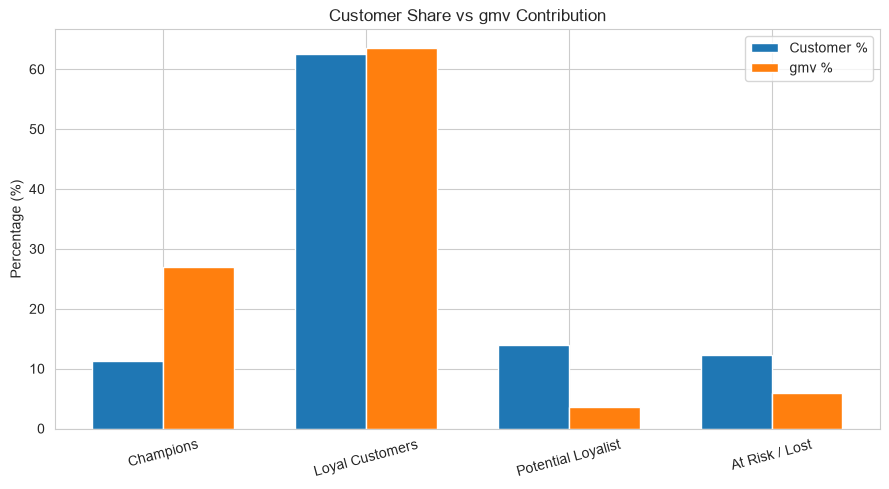

In [12]:
fig, ax = plt.subplots(figsize=(9,5))

x = np.arange(len(segment_summary))
width = 0.35

ax.bar(
    x - width/2,
    segment_summary['customer_pct'],
    width,
    label='Customer %'
)

ax.bar(
    x + width/2,
    segment_summary['gmv_pct'],
    width,
    label='gmv %'
)

ax.set_xticks(x)
ax.set_xticklabels(segment_summary.index, rotation=15)

ax.set_ylabel('Percentage (%)')
ax.set_title('Customer Share vs gmv Contribution')
ax.legend()

plt.tight_layout()
plt.show()